## Ptychography with the Ptychographic Iterative Engine (PIE)

The previous notebook covered single-shot phase retrieval:

$$
I(k_x,k_y)=|\mathcal{F}\{U(x,y)\}|^2.
$$

That problem is difficult because we only have one intensity pattern and we rely heavily on support constraints.

Ptychography changes the situation. Instead of one diffraction pattern, we illuminate the object with a localized probe at many overlapping positions and measure a diffraction pattern for each position:

$$
I_j(k_x,k_y)
=
\left|
\mathcal{F}\left[
P_j(x,y)\,O(x,y)
\right]
\right|^2.
$$

The overlap between neighboring illuminated regions creates redundancy. This redundancy is the key reason ptychography is much more robust than single-shot CDI.


### Big picture

In basic ptychography, we have:

- an unknown object:

$$
O(x,y)
$$

- a known localized probe / illumination spot:

$$
P(x,y)
$$

- shifted copies of the probe:

$$
P_j(x,y)=P(x-X_j,y-Y_j)
$$

- an exit wave at each scan position:

$$
\psi_j(x,y)=P_j(x,y)O(x,y)
$$

- a measured far-field diffraction intensity:

$$
I_j(k_x,k_y)=|\hat{\psi}_j(k_x,k_y)|^2
$$

where:

$$
\hat{\psi}_j = \mathcal{F}\{\psi_j\}.
$$

The inverse problem is:

> Given $P_j$, scan positions $(X_j,Y_j)$, and measured intensities $I_j$, reconstruct $O(x,y)$.

This notebook assumes the probe is known. The next ptychography step would be **ePIE**, where both object and probe are reconstructed.



### PIE steps:

1. Define a complex object $O$.
2. Define a localized complex probe $P$, with phase structure similar to a diffuser.
3. Shift the probe to a small grid of positions.
4. For each position, calculate the synthetic measured diffraction intensity:

   $$
   I_j = |\mathcal{F}\{P_j O\}|^2.
   $$

5. Start from an object estimate:

   $$
   O_\text{est}=1.
   $$

6. For each scan position:
   - calculate the estimated exit wave:

     $$
     \psi_{j,\text{est}}=P_j O_\text{est}
     $$

   - Fourier-transform it;
   - replace the Fourier amplitude with the measured amplitude:

     $$
     \hat{\psi}_{j,\text{upd}}
     =
     \sqrt{I_j}
     \frac{\hat{\psi}_{j,\text{est}}}{|\hat{\psi}_{j,\text{est}}|}
     $$

   - inverse-transform back:

     $$
     \psi_{j,\text{upd}}=\mathcal{F}^{-1}\{\hat{\psi}_{j,\text{upd}}\}
     $$

   - update the object using the difference:

     $$
     O_\text{est}
     \leftarrow
     O_\text{est}
     +
     \frac{P_j^*}{\max |P_j|^2}
     \left(
     \psi_{j,\text{upd}}-\psi_{j,\text{est}}
     \right).
     $$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

### Fourier functions

In [2]:
def F2d(u):
    """Centered, unitary 2D Fourier transform."""
    return np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(u)))

def iF2d(u):
    """Centered, unitary 2D Fourier transform."""
    return np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(u)))

### Define object and probe

#### Object

The object is a complex transmission function:

$$
O(x,y)=A(x,y)e^{i\phi(x,y)}.
$$

Its amplitude tells us how much light is transmitted.  
Its phase tells us how much the sample delays the wave.

We build a synthetic object from several phase features.

#### Probe

The probe is the localized illumination field:

$$
P(x,y).
$$

We use a circular probe with a spatially varying phase:

$$
P(x,y)=e^{2\pi i D(x,y)} \cdot \mathbf{1}_{R\leq 0.1}.
$$

This behaves like a small complex illumination spot, somewhat like a diffuser-limited probe.

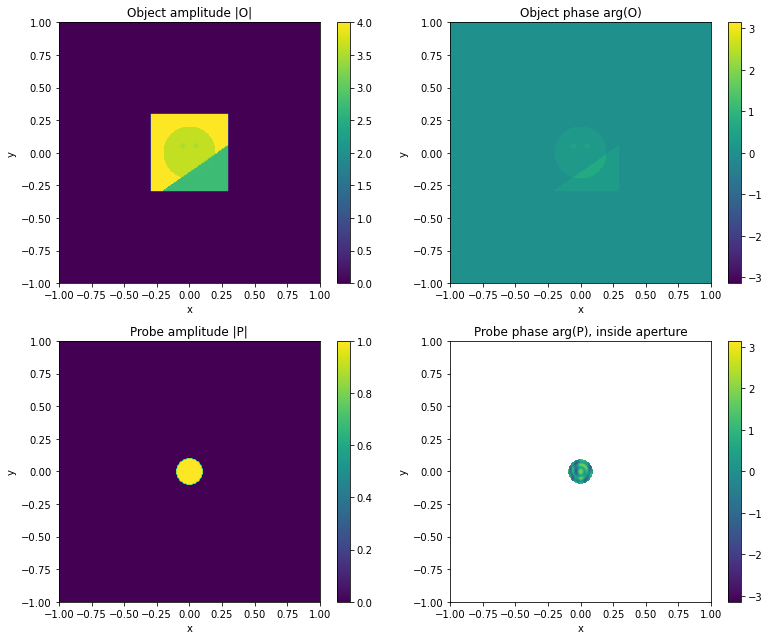

In [3]:

# For a higher-resolution portfolio run, change N to 256.
N = 256

x = np.linspace(-1, 1, N)
X, Y = np.meshgrid(x, x, indexing="xy")
R = np.sqrt(X**2 + Y**2)

# --- Complex object ---
support = (np.abs(X) < 0.3) & (np.abs(Y) < 0.3)

O = np.exp(1j * 2 * ((0.7 * X - Y) > 0.15))
O = O + np.exp(1j * ((X**2 + Y**2) < 0.04))
O = O + np.exp(1j * (np.sqrt((X - 0.05)**2 + (Y - 0.05)**2) < 0.02))
O = O + np.exp(1j * (np.sqrt((X + 0.05)**2 + (Y - 0.05)**2) < 0.02))

# Localize object for clearer visualization.
O = support * O

# --- Complex probe / diffuser-like illumination spot ---
Diffuser = np.mod(
    0.1 * (
        np.sin(150 * R)
        + np.cos((Y * 10 + X * 30)**2 - 0.8 * (X * 75 - 0.2))
        + np.cos((Y * 10 - X * 33)**2 - 0.4 * (X * 50 - 0.2))
    ),
    1,
)

P = np.exp(2 * np.pi * 1j * Diffuser) * (R <= 0.1)

fig, axes = plt.subplots(2, 2, figsize=(11, 9))

im00 = axes[0, 0].imshow(np.abs(O), extent=[x[0], x[-1], x[0], x[-1]], origin="lower")
axes[0, 0].set_title("Object amplitude |O|")
axes[0, 0].set_xlabel("x")
axes[0, 0].set_ylabel("y")
plt.colorbar(im00, ax=axes[0, 0], fraction=0.046)

im01 = axes[0, 1].imshow(np.angle(O), extent=[x[0], x[-1], x[0], x[-1]], origin="lower", vmin=-np.pi, vmax=np.pi)
axes[0, 1].set_title("Object phase arg(O)")
axes[0, 1].set_xlabel("x")
axes[0, 1].set_ylabel("y")
plt.colorbar(im01, ax=axes[0, 1], fraction=0.046)

im10 = axes[1, 0].imshow(np.abs(P), extent=[x[0], x[-1], x[0], x[-1]], origin="lower")
axes[1, 0].set_title("Probe amplitude |P|")
axes[1, 0].set_xlabel("x")
axes[1, 0].set_ylabel("y")
plt.colorbar(im10, ax=axes[1, 0], fraction=0.046)

# Phase is only meaningful where probe amplitude is nonzero.
probe_phase_display = np.angle(P).copy()
probe_phase_display[np.abs(P) < 1e-12] = np.nan

im11 = axes[1, 1].imshow(probe_phase_display, extent=[x[0], x[-1], x[0], x[-1]], origin="lower", vmin=-np.pi, vmax=np.pi)
axes[1, 1].set_title("Probe phase arg(P), inside aperture")
axes[1, 1].set_xlabel("x")
axes[1, 1].set_ylabel("y")
plt.colorbar(im11, ax=axes[1, 1], fraction=0.046)

plt.tight_layout()
plt.show()


The object is localized and complex-valued.

The probe is also complex-valued, but localized in a circular aperture. Outside the probe aperture, \(P=0\), so the object is not illuminated there for that scan position.

This matters for the update:

$$
O_\text{est}
\leftarrow
O_\text{est}
+
\frac{P_j^*}{\max |P_j|^2}
\left(
\psi_{j,\text{upd}}-\psi_{j,\text{est}}
\right).
$$

Where the probe amplitude is zero, $P_j^*=0$, so the object is not updated.  
Where the probe is strong, the update is strong.

### Define probe scan positions

We use five x-shifts and five y-shifts, giving $5\times5=25$ diffraction measurements.

The shifts are in **pixels**:

```matlab
xshiftvec = [-15 -8 0 7 16]
yshiftvec = [-16 -9 0 8 17]
```

These positions are deliberately close enough that neighboring probe illuminations overlap.

Why overlap matters:

- if two adjacent probe positions overlap, they share object pixels;
- the reconstruction must assign the same object value to the shared region;
- this shared-region consistency links the unknown phases of different diffraction patterns.


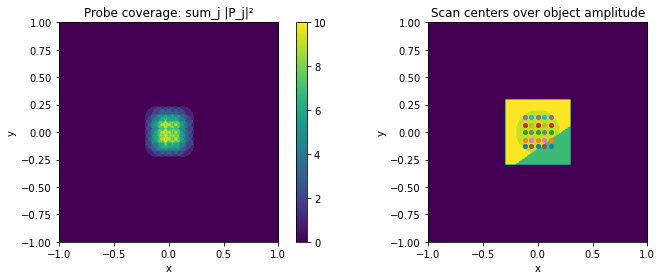

In [4]:

xshiftvec = np.array([-15, -8, 0, 7, 16])
yshiftvec = np.array([-16, -9, 0, 8, 17])

# List of scan positions: (x_shift_pixels, y_shift_pixels)
positions = [(xs, ys) for xs in xshiftvec for ys in yshiftvec]

def shift_probe(P, x_shift, y_shift):
    """
    Shift probe by integer pixels

    NumPy:
        np.roll(P, shift=(yshift, xshift), axis=(0, 1))

    Axis 0 corresponds to rows/y.
    Axis 1 corresponds to columns/x.
    """
    return np.roll(P, shift=(y_shift, x_shift), axis=(0, 1))


# Coverage map: how much each object pixel is illuminated across all scan positions.
coverage = np.zeros_like(R, dtype=float)
for xs, ys in positions:
    P_shift = shift_probe(P, xs, ys)
    coverage += np.abs(P_shift)**2

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

im0 = axes[0].imshow(coverage, extent=[x[0], x[-1], x[0], x[-1]], origin="lower")
axes[0].set_title("Probe coverage: sum_j |P_j|²")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
plt.colorbar(im0, ax=axes[0], fraction=0.046)

# Overlay scan centers in physical coordinates.
axes[1].imshow(np.abs(O), extent=[x[0], x[-1], x[0], x[-1]], origin="lower")
for xs in xshiftvec:
    for ys in yshiftvec:
        axes[1].plot(xs * (x[1] - x[0]), ys * (x[1] - x[0]), "o", markersize=4)
axes[1].set_title("Scan centers over object amplitude")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")

plt.tight_layout()
plt.show()


The coverage map shows:

$$
C(x,y)=\sum_j |P_j(x,y)|^2.
$$

Pixels with high coverage are illuminated by many probe positions. Those regions are strongly constrained.

Pixels with zero coverage are never illuminated. They cannot be reconstructed from these measurements.

This demonestrates:

> Ptychography reconstructs the region that has been sufficiently illuminated, not magically the whole computational grid.

In experiments, scan design matters: step size, overlap, total field of view, and probe size all affect reconstruction quality.


### Generate synthetic ptychographic measurements

For each scan position $j$:

1. Shift the probe:

   $$
   P_j(x,y)=P(x-X_j,y-Y_j)
   $$

2. Multiply object and shifted probe:

   $$
   \psi_j(x,y)=P_j(x,y)O(x,y)
   $$

3. Fourier-transform the exit wave:

   $$
   \hat{\psi}_j(k_x,k_y)=\mathcal{F}\{\psi_j(x,y)\}
   $$

4. Store the intensity:

   $$
   I_j(k_x,k_y)=|\hat{\psi}_j(k_x,k_y)|^2.
   $$

These synthetic intensities are the simulated camera measurements.


In [5]:

# Store measured Fourier amplitudes instead of intensities.
# The algorithm needs sqrt(I_j), so storing amplitudes avoids repeated square roots.
measured_amplitudes = []

# Also store some example diffraction intensities for visualization.
example_intensities = []
example_exit_waves = []

for idx, (xs, ys) in enumerate(positions):
    P_shift = shift_probe(P, xs, ys)
    psi = P_shift * O
    I = np.abs(F2d(psi))**2
    measured_amplitudes.append(np.sqrt(I))

    if idx in [0, 6, 12, 18, 24]:
        example_intensities.append(I)
        example_exit_waves.append(psi)

measured_amplitudes = np.array(measured_amplitudes)

print("Number of scan positions:", len(positions))
print("Shape of measured_amplitudes:", measured_amplitudes.shape)


Number of scan positions: 25
Shape of measured_amplitudes: (25, 256, 256)


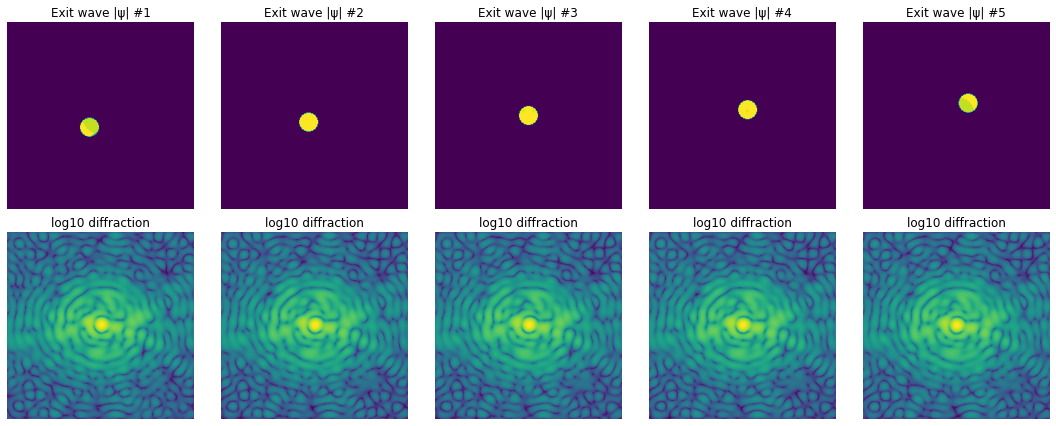

In [6]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for col, (psi, I) in enumerate(zip(example_exit_waves, example_intensities)):
    axes[0, col].imshow(np.abs(psi), origin="lower")
    axes[0, col].set_title(f"Exit wave |ψ| #{col+1}")
    axes[0, col].set_axis_off()

    axes[1, col].imshow(np.log10(I + 1), origin="lower")
    axes[1, col].set_title("log10 diffraction")
    axes[1, col].set_axis_off()

plt.tight_layout()
plt.show()

Each exit wave is only a local illuminated patch of the object.

Each diffraction pattern is the far-field intensity of that local patch.

The diffraction patterns look different because the probe illuminates different parts of the object. However, neighboring patches overlap, so the corresponding diffraction patterns are not independent. They are linked by shared object pixels.

### PIE reconstruction algorithm

Now we reconstruct the object.

#### Start with an object guess

We start with:

$$
O_\text{est}(x,y)=1.
$$

This means we initially assume a flat transparent object.

#### For one scan position

Given the current estimate $O_\text{est}$:

$$
\psi_{j,\text{est}}=P_jO_\text{est}.
$$

Fourier transform:

$$
\hat{\psi}_{j,\text{est}}=\mathcal{F}\{\psi_{j,\text{est}}\}.
$$

Enforce measured Fourier amplitude:

$$
\hat{\psi}_{j,\text{upd}}
=
\sqrt{I_j}
\exp\left(i\arg \hat{\psi}_{j,\text{est}}\right).
$$

Inverse transform:

$$
\psi_{j,\text{upd}}
=
\mathcal{F}^{-1}\{\hat{\psi}_{j,\text{upd}}\}.
$$

The exit-wave correction is:

$$
\Delta \psi_j
=
\psi_{j,\text{upd}}-\psi_{j,\text{est}}.
$$

Since:

$$
\psi_j=P_jO,
$$

we update the object using the complex conjugate of the probe:

$$
O_\text{est}
\leftarrow
O_\text{est}
+
\alpha
\frac{P_j^*}{\max |P_j|^2}
\Delta \psi_j.
$$

Here $\alpha$ is a relaxation factor. We use $\alpha=1$ by default.


In [7]:

def enforce_measured_amplitude(psi_est, measured_amplitude):
    """
    Apply the Fourier modulus constraint to one estimated exit wave.

    Input:
        psi_est            : estimated exit wave in object plane.
        measured_amplitude : measured |F{psi_true}| for this scan position.

    Output:
        psi_upd : updated exit wave after enforcing measured Fourier amplitude.
    """
    psi_hat_est = F2d(psi_est)
    psi_hat_upd = measured_amplitude * np.exp(1j * np.angle(psi_hat_est))
    psi_upd = iF2d(psi_hat_upd)
    return psi_upd


def pie_update_object(O_est, P_shift, measured_amplitude, alpha=1.0, eps=1e-12):
    """
    One PIE object update for one scan position.

    This assumes:
        - known probe P_shift
        - known measured diffraction amplitude for this position
        - unknown object O_est

    Returns:
        updated object estimate
    """
    psi_est = P_shift * O_est
    psi_upd = enforce_measured_amplitude(psi_est, measured_amplitude)
    delta_psi = psi_upd - psi_est

    denom = np.max(np.abs(P_shift)**2) + eps

    O_est_new = O_est + alpha * np.conj(P_shift) * delta_psi / denom
    return O_est_new


def align_global_complex_scale(O_est, O_true, mask):
    """
    Align the global complex scale/phase of O_est to O_true inside mask.

    Ptychographic intensity data cannot determine an arbitrary global phase,
    so this alignment is only for error measurement and display.
    """
    numerator = np.vdot(O_est[mask], O_true[mask])
    denominator = np.vdot(O_est[mask], O_est[mask]) + 1e-12
    alpha = numerator / denominator
    return alpha * O_est, alpha


def object_error(O_est, O_true, mask):
    """
    Relative object error after global complex alignment.
    """
    O_aligned, _ = align_global_complex_scale(O_est, O_true, mask)
    return np.linalg.norm((O_aligned - O_true)[mask]) / np.linalg.norm(O_true[mask])


def diffraction_error_for_dataset(O_est, P, positions, measured_amplitudes):
    """
    Average relative Fourier-amplitude error over all scan positions.
    """
    errs = []
    for (xs, ys), measured_amp in zip(positions, measured_amplitudes):
        P_shift = shift_probe(P, xs, ys)
        psi_est = P_shift * O_est
        amp_est = np.abs(F2d(psi_est))
        errs.append(np.linalg.norm(amp_est - measured_amp) / np.linalg.norm(measured_amp))
    return float(np.mean(errs))


### Run the reconstruction

We reconstruct only where the object is actually illuminated. For error metrics, we use a mask based on the coverage map:

$$
C(x,y)=\sum_j |P_j(x,y)|^2.
$$

The reconstruction outside this region is not meaningful.

In [8]:

# Region where the reconstruction is meaningful.
reconstruction_mask = coverage > 0.1 * np.max(coverage)

# Reconstruction settings.
num_epochs = 30
alpha = 1.0

# Initial guess
O_est = np.ones_like(O, dtype=complex)

object_errors = []
diffraction_errors = []

# For visualization, save a few intermediate estimates.
saved_epochs = [0, 1, 3, 10, 30]
saved_estimates = {}

# Save initial guess.
saved_estimates[0] = O_est.copy()
object_errors.append(object_error(O_est, O, reconstruction_mask))
diffraction_errors.append(diffraction_error_for_dataset(O_est, P, positions, measured_amplitudes))

for epoch in range(1, num_epochs + 1):
    for idx, (xs, ys) in enumerate(positions):
        P_shift = shift_probe(P, xs, ys)
        measured_amp = measured_amplitudes[idx]
        O_est = pie_update_object(O_est, P_shift, measured_amp, alpha=alpha)

    object_errors.append(object_error(O_est, O, reconstruction_mask))
    diffraction_errors.append(diffraction_error_for_dataset(O_est, P, positions, measured_amplitudes))

    if epoch in saved_epochs:
        saved_estimates[epoch] = O_est.copy()

print(f"Initial object error: {object_errors[0]:.4f}")
print(f"Final object error:   {object_errors[-1]:.4f}")
print(f"Initial diffraction amplitude error: {diffraction_errors[0]:.4f}")
print(f"Final diffraction amplitude error:   {diffraction_errors[-1]:.4f}")


Initial object error: 0.1984
Final object error:   0.0000
Initial diffraction amplitude error: 0.7211
Final diffraction amplitude error:   0.0000


### Reconstruction results

We now compare:

- true object amplitude and phase;
- reconstructed object amplitude and phase;
- error curves.

Note: the global phase/scale is aligned for display and error calculation. The global phase is physically unobservable from intensity-only measurements.

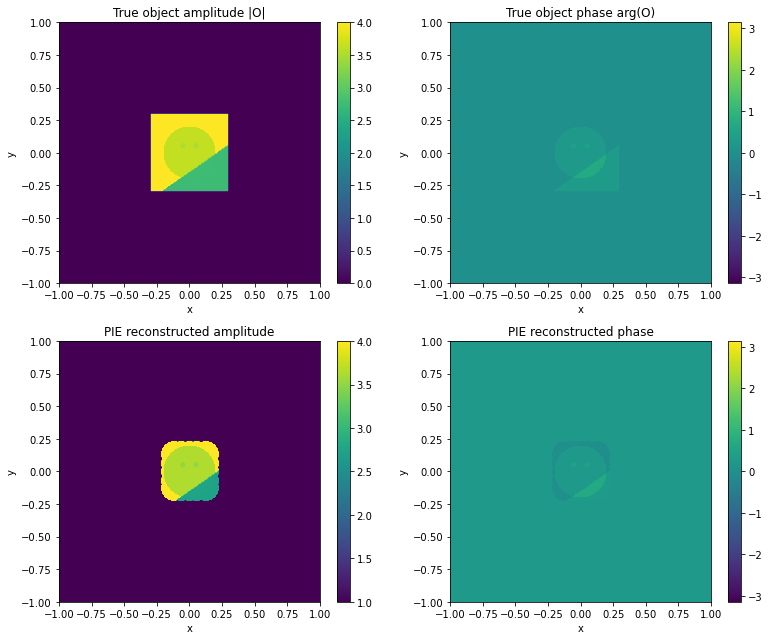

In [9]:

O_est_aligned, _ = align_global_complex_scale(O_est, O, reconstruction_mask)

fig, axes = plt.subplots(2, 2, figsize=(11, 9))

im00 = axes[0, 0].imshow(np.abs(O), extent=[x[0], x[-1], x[0], x[-1]], origin="lower")
axes[0, 0].set_title("True object amplitude |O|")
axes[0, 0].set_xlabel("x")
axes[0, 0].set_ylabel("y")
plt.colorbar(im00, ax=axes[0, 0], fraction=0.046)

im01 = axes[0, 1].imshow(np.angle(O), extent=[x[0], x[-1], x[0], x[-1]], origin="lower", vmin=-np.pi, vmax=np.pi)
axes[0, 1].set_title("True object phase arg(O)")
axes[0, 1].set_xlabel("x")
axes[0, 1].set_ylabel("y")
plt.colorbar(im01, ax=axes[0, 1], fraction=0.046)

im10 = axes[1, 0].imshow(np.abs(O_est_aligned), extent=[x[0], x[-1], x[0], x[-1]], origin="lower")
axes[1, 0].set_title("PIE reconstructed amplitude")
axes[1, 0].set_xlabel("x")
axes[1, 0].set_ylabel("y")
plt.colorbar(im10, ax=axes[1, 0], fraction=0.046)

phase_display = np.angle(O_est_aligned)
im11 = axes[1, 1].imshow(phase_display, extent=[x[0], x[-1], x[0], x[-1]], origin="lower", vmin=-np.pi, vmax=np.pi)
axes[1, 1].set_title("PIE reconstructed phase")
axes[1, 1].set_xlabel("x")
axes[1, 1].set_ylabel("y")
plt.colorbar(im11, ax=axes[1, 1], fraction=0.046)

plt.tight_layout()
plt.show()


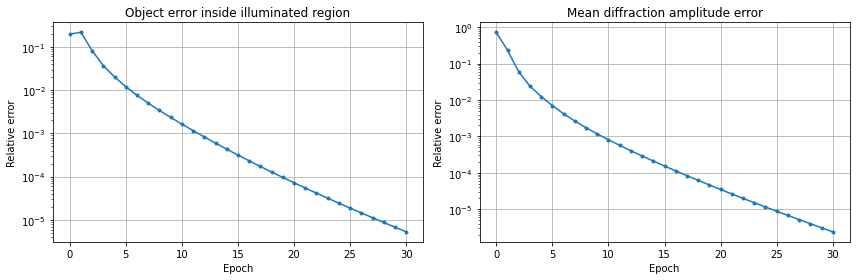

In [10]:

epochs = np.arange(num_epochs + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].semilogy(epochs, object_errors, marker="o", markersize=3)
axes[0].set_title("Object error inside illuminated region")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Relative error")
axes[0].grid(True)

axes[1].semilogy(epochs, diffraction_errors, marker="o", markersize=3)
axes[1].set_title("Mean diffraction amplitude error")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Relative error")
axes[1].grid(True)

plt.tight_layout()
plt.show()


#### Result reasoning

The reconstruction improves because each scan position imposes a Fourier-amplitude constraint on a different local exit wave.

Because the patches overlap, the updates reinforce object features that are consistent across measurements and suppress inconsistent features.

The error curves drop rapidly at first, then more slowly. This is typical for iterative inverse problems:

- early iterations recover large-scale structure;
- later iterations refine phase and smaller features;
- convergence can slow because the remaining errors are harder constraint conflicts or numerical artifacts.

### Evolution over iterations

Let's visualize the object estimate at several epochs.

- at epoch 0, the estimate is a flat object;
- after a few epochs, the illuminated region starts forming;
- after many epochs, amplitude and phase approach the true object.


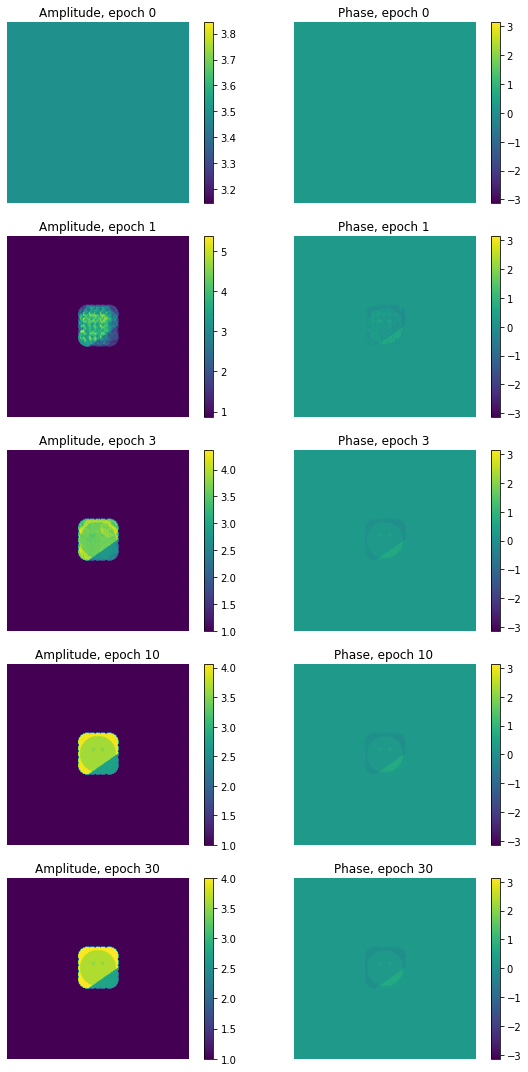

In [11]:

fig, axes = plt.subplots(len(saved_epochs), 2, figsize=(9, 3 * len(saved_epochs)))

for row, ep in enumerate(saved_epochs):
    O_ep = saved_estimates[ep]
    O_ep_aligned, _ = align_global_complex_scale(O_ep, O, reconstruction_mask)

    im0 = axes[row, 0].imshow(np.abs(O_ep_aligned), origin="lower")
    axes[row, 0].set_title(f"Amplitude, epoch {ep}")
    axes[row, 0].set_axis_off()
    plt.colorbar(im0, ax=axes[row, 0], fraction=0.046)

    im1 = axes[row, 1].imshow(np.angle(O_ep_aligned), origin="lower", vmin=-np.pi, vmax=np.pi)
    axes[row, 1].set_title(f"Phase, epoch {ep}")
    axes[row, 1].set_axis_off()
    plt.colorbar(im1, ax=axes[row, 1], fraction=0.046)

plt.tight_layout()
plt.show()


PIE is not reconstructing the object by “backpropagating one image.”  
It is gradually making the object estimate compatible with **all local diffraction measurements**.

The algorithm is sequential:

$$
O_\text{est}
\rightarrow
\text{update from scan position 1}
\rightarrow
\text{update from scan position 2}
\rightarrow
\cdots
\rightarrow
\text{update from scan position 25}.
$$

One full pass over all scan positions is one epoch.
